# Decision-Making Algorithm Comparison (Including Decision Trees, Monte Carlo Tree Search and Markov Decision Process)

In [3]:
# Imports
import os
import gc
import warnings
import numpy as np
import pandas as pd
from time import perf_counter
import time, math, matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import math, random
from dataclasses import dataclass, field
from typing import List, Optional, Tuple
import gymnasium as gym
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
warnings.filterwarnings("ignore")

## Decision Tree Regression on the California Housing Dataset

For this analysis, a Decision Tree Regressor was implemented to predict median housing values using the California Housing Prices dataset from Kaggle (https://www.kaggle.com/datasets/camnugent/california-housing-prices). The process began with data loading and preprocessing, followed by splitting the data into training and testing sets (80/20). A grid search with 5-fold cross-validation was performed to tune key hyperparameters such as maximum depth, minimum samples per leaf, and cost-complexity pruning (α). The model’s performance was evaluated using Root Mean Squared Error (RMSE) and R² on the test set, and the most influential predictors were identified through feature importance ranking. Finally, a pruned tree visualization was generated to interpret decision paths and highlight the key variables driving housing price predictions.

In [6]:
# Load local Kaggle file
df = pd.read_csv("housing.csv")

# Split features/target
y = df["median_house_value"]
X = df.drop(columns=["median_house_value"])

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist() 

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ]
)

pipe = Pipeline(steps=[
    ("pre", preprocessor),
    ("dt", DecisionTreeRegressor(random_state=42))
])

# Train/test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision tree parameter grid
param_grid = {
    "dt__criterion": ["squared_error", "friedman_mse"],
    "dt__max_depth": [10, 15, 25, 35, None],
    "dt__min_samples_leaf": [5, 10, 15, 25],
    "dt__ccp_alpha": [0.0, 0.001, 0.01]
}

reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

reg = GridSearchCV(pipe, param_grid=param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=1)
reg.fit(X_train, y_train)
best_dt = reg.best_estimator_.named_steps["dt"]

print("Best parameters:", reg.best_params_)
print("Tree depth:", best_dt.get_depth(), "| Leaves:", best_dt.get_n_leaves())

Best parameters: {'dt__ccp_alpha': 0.0, 'dt__criterion': 'squared_error', 'dt__max_depth': 15, 'dt__min_samples_leaf': 15}
Tree depth: 15 | Leaves: 784


The optimal paraeters chosen by the parameter grid search were a ccp_alpha value of 0, a criterion using squared error, a max tree depth of 15, and a minimum samples per leaf of 15. This resulted in 784 total leaves; a modest amount that was likely limited by the minimum leafs per node constraint. Next I evaluate the trained decision tree model on our test set and report the RMSE and R^2.

In [8]:
# Test set Eval
y_pred = reg.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("\n=== Test Metrics ===")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")


=== Test Metrics ===
RMSE: 58342.855
R²  : 0.740


The optimized Decision Tree Regressor achieved a Root Mean Squared Error (RMSE) of approximately 58,343 USD and an R² value of 0.74 on the test set. This indicates that the model explains roughly 74% of the variance in median housing prices across California districts, with an average prediction error of about $58K compared to true home values. Given the inherent variability of housing data and the non-linear nature of regional housing markets, I'm pleased with the .74 R^2 and believe that further improvements could be made via ensemble methods or feature engineering.

,feature,importance
7,median_income,0.557572
9,ocean_proximity_INLAND,0.171264
0,longitude,0.097686
1,latitude,0.089212
2,housing_median_age,0.035961
5,population,0.014407
4,total_bedrooms,0.010705
12,ocean_proximity_NEAR OCEAN,0.007698
3,total_rooms,0.007110
6,households,0.006946


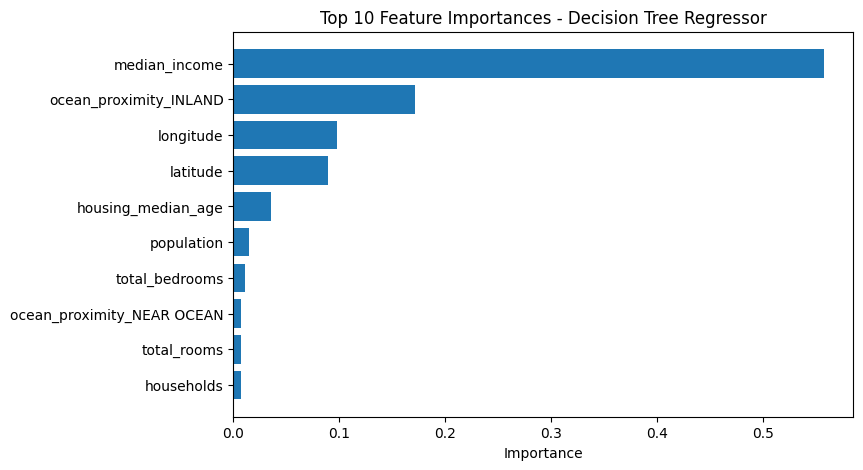

In [10]:
# Feature Ranking
ohe = reg.best_estimator_.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
num_features = numeric_features
cat_features = ohe.get_feature_names_out(categorical_features)
all_features = np.concatenate([num_features, cat_features])


fi = (
    pd.DataFrame({"feature": all_features, "importance": best_dt.feature_importances_})
    .sort_values("importance", ascending=False)
)
display(fi.head(10))


plt.figure(figsize=(8,5))
plt.barh(fi["feature"].head(10), fi["importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Decision Tree Regressor")
plt.xlabel("Importance")
plt.show()

Feature ranking via total RMSE reduction revealed that median_income was by far the strongest predictor of housing value, accounting for more than half of the total model importance (55.8%). The next most influential variable was ocean_proximity_INLAND (17.1%), indicating that distance from the coast plays a substantial role in predicting property values. Geographic coordinates longitude and latitude also contributed meaningfully (18.7% combined). In contrast, structural and demographic factors such as housing_median_age, population, and total_bedrooms showed smaller contributions. Lastly we can visualize the upper portion of the decision tree to gain insight into how the splits occured. 

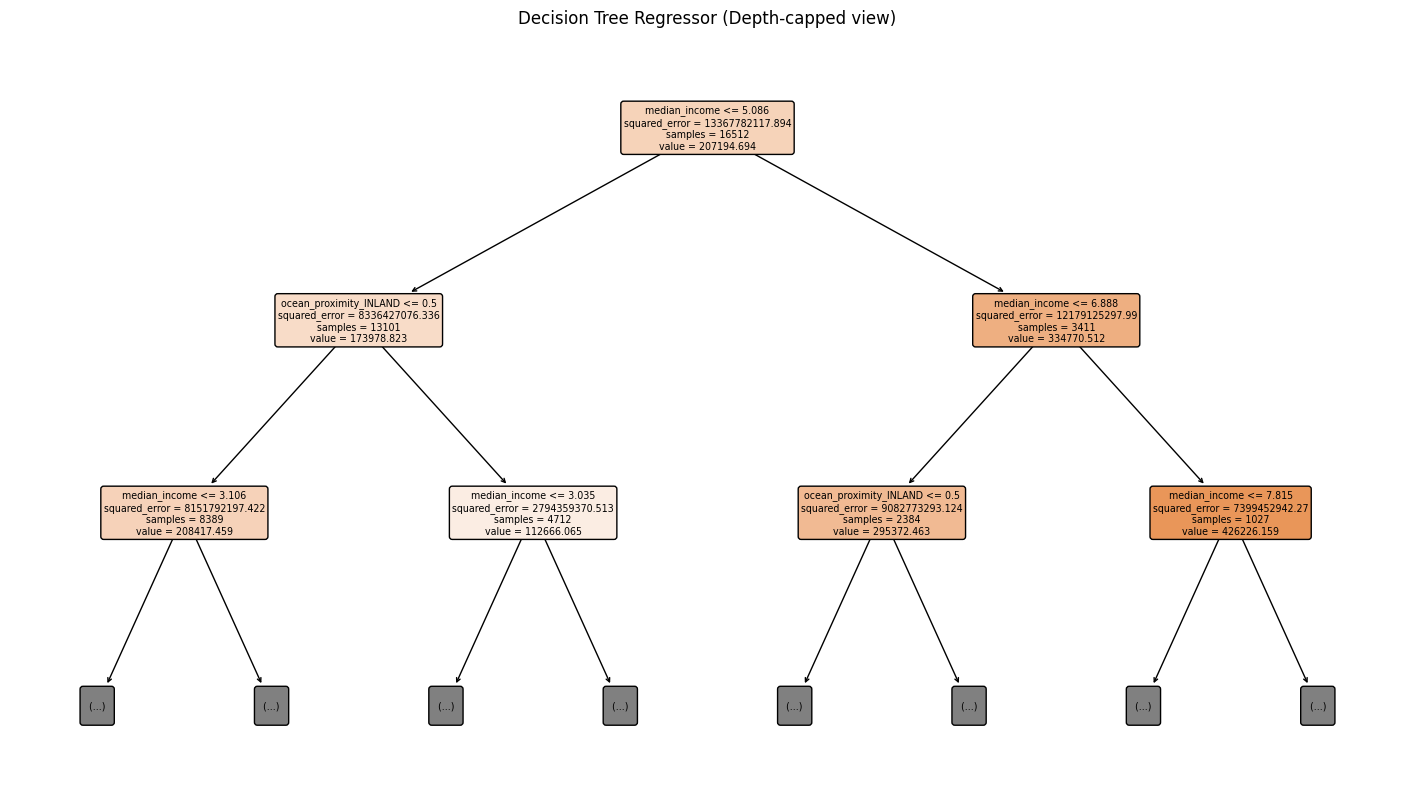

                                         best_params          rmse        r2  \
0  {'dt__ccp_alpha': 0.0, 'dt__criterion': 'squar...  58342.855403  0.740242   

   depth  leaves  
0     15     784  


<Figure size 640x480 with 0 Axes>

In [49]:
# Visualization
plt.figure(figsize=(18,10))
plot_tree(
    best_dt,
    feature_names=all_features,
    filled=True,
    rounded=True,
    max_depth=2
)
plt.title("Decision Tree Regressor (Depth-capped view)")
plt.show()

# Summary
summary = pd.DataFrame([{
    "best_params": str(reg.best_params_),
    "rmse": rmse,
    "r2": r2,
    "depth": best_dt.get_depth(),
    "leaves": best_dt.get_n_leaves()
}])
print(summary)
plt.savefig("decision_tree_full.png", dpi=300, bbox_inches="tight")
plt.savefig("decision_tree_full.pdf", bbox_inches="tight")  # PDF version

The decision tree’s top splits confirm median_income as the dominant driver of California home values, with higher-income districts branching to markedly higher predictions.
Geographic factors like longitude (west/east) and latitude (north/south) form the next layers, separating coastal areas from inland areas.
Structural/demographic variables like housing_median_age, total_bedrooms, and population appear deeper in the tree, providing localized refinements but smaller variance reductions.
Terminal nodes span a wide range (roughly 80K–470K), reflecting California’s heterogeneous markets.
Overall, the tree yields an interpretable segmentation where income and location jointly explain most price variation, aligning with the feature-importance ranking and real-world housing dynamics.

## Monte Carlo Tree Search for Tic-Tac-Toe

To model sequential decision-making in a dynamic, uncertain environment, a Monte Carlo Tree Search (MCTS) algorithm was implemented below using the game of Tic-Tac-Toe. MCTS combines stochastic simulation with tree-based search to evaluate potential future moves through four iterative phases: Selection, Expansion, Simulation, and Backpropagation; guided by the Upper Confidence Bound (UCB1) formula to balance exploration and exploitation. Each move selection involves simulating thousands of random playthroughs (n_simulations = 1000), where the outcomes of these rollouts refine the estimated value of actions over time. The implementation uses a custom Tic-Tac-Toe environment to manage game logic, legal moves, and win conditions, allowing the MCTS agent to make optimal move decisions without explicit heuristics or prior knowledge. Model performance is measured through repeated games against random and heuristic opponents, recording win/draw/loss rates and average decision time per move. This setup demonstrates how MCTS can achieve strong strategic play through probabilistic search rather than deterministic rules.

In [16]:
# Establish Game environment
class TTT:
    # X = +1, O = -1, empty = 0
    WIN_LINES = [(0,1,2),(3,4,5),(6,7,8),
                 (0,3,6),(1,4,7),(2,5,8),
                 (0,4,8),(2,4,6)]
    def __init__(self):
        self.board = [0]*9
        self.player = 1  # X starts

    def copy(self):
        g = TTT()
        g.board = self.board[:]
        g.player = self.player
        return g

    def legal_moves(self) -> List[int]:
        return [i for i,v in enumerate(self.board) if v == 0]

    def play(self, a: int) -> None:
        self.board[a] = self.player
        self.player *= -1

    def undo(self, a: int) -> None:
        self.player *= -1
        self.board[a] = 0

    def winner(self) -> int:
        # returns +1 (X win), -1 (O win), 2 (draw), 0 (ongoing)
        for i,j,k in self.WIN_LINES:
            s = self.board[i] + self.board[j] + self.board[k]
            if s == 3:  return 1
            if s == -3: return -1
        return 0 if any(v == 0 for v in self.board) else 2

    def key(self) -> Tuple[int, ...]:
        # hashable state key for transposition table if needed
        return (*self.board, self.player)

This section defines a self-contained Tic-Tac-Toe game environment used by the MCTS algorithm. The class manages the game board, valid moves, player turns, and win conditions through simple integer-based logic. It includes helper methods to simulate and undo moves, enabling the tree search to explore possible futures without affecting the original game.

In [18]:
# MCTS Node Class
@dataclass
class Node:
    state_key: Tuple[int, ...]
    parent: Optional["Node"]
    action: Optional[int]
    N: int = 0           # visit count
    W: float = 0.0       # total value from this node's perspective
    children: List["Node"] = field(default_factory=list)
    untried: List[int] = field(default_factory=list)

# MCTS UCT Function
class MCTS:
    def __init__(self, n_simulations: int = 1000, C: float = math.sqrt(2)):
        self.n_simulations = n_simulations
        self.C = C

    def select(self, node: Node) -> Node:
        # UCB1: Q/N + C * sqrt(ln N_parent / N_child)
        while not node.untried and node.children:
            node = max(
                node.children,
                key=lambda n: (n.W / n.N) + self.C * math.sqrt(math.log(node.parent.N) / n.N)
            )
        return node

    def expand(self, node: Node, game: TTT) -> Node:
        if node.untried:
            a = random.choice(node.untried)
            game.play(a)
            child = Node(state_key=game.key(), parent=node, action=a,
                         untried=game.legal_moves())
            node.children.append(child)
            node = child
        return node

    def simulate(self, game: TTT) -> int:
        # random rollout: return +1 if current player (before call) eventually wins from node.parent's perspective
        # We define rollout reward from the viewpoint of the player to move at the node.
        current_player = game.player
        while game.winner() == 0:
            game.play(random.choice(game.legal_moves()))
        res = game.winner()
        if res == 2:  # draw
            return 0
        # if winner equals current_player, return +1 else -1
        return 1 if res == current_player else -1

    def backprop(self, node: Node, value: int) -> None:
        # alternate sign as we go up (each level switches perspective)
        while node is not None:
            node.N += 1
            node.W += value
            value = -value
            node = node.parent

    def best_move(self, game: TTT) -> int:
        root = Node(state_key=game.key(), parent=None, action=None,
                    untried=game.legal_moves())
        for _ in range(self.n_simulations):
            g = game.copy()
            node = root

            # Selection
            node = self.select(node)

            # Expansion (if possible)
            node = self.expand(node, g)

            # Simulation
            value = self.simulate(g)

            # Backpropagation
            self.backprop(node, value)

        # choose child with highest visit count
        best_child = max(root.children, key=lambda n: n.N)
        return best_child.action

This section defines the logic behind the Monte Carlo Tree Search algorithm. The Node dataclass stores the structure of the game tree, tracking each state’s visit count, reward, and possible actions. The MCTS class then performs iterative simulations to estimate the value of each move through four key steps: Selection (choosing promising nodes using UCB1), Expansion (adding new nodes to explore unseen actions), Simulation (randomly playing out games to estimate outcomes), and Backpropagation (updating node statistics based on results). Over thousands of simulations, these statistics converge toward optimal decision-making, allowing the algorithm to balance exploration of new moves with exploitation of known strong strategies.

In [20]:
# Opponent Agents
def random_agent(game: TTT) -> int:
    return random.choice(game.legal_moves())

def heuristic_agent(game: TTT) -> int:
    # Simple 1-ply: win if possible, block if needed, else center > corners > sides
    me = game.player
    opp = -me
    moves = game.legal_moves()

    # try to win
    for a in moves:
        game.play(a)
        if game.winner() == me:
            game.undo(a); return a
        game.undo(a)
    # block opponent
    for a in moves:
        game.play(a)
        if game.winner() == opp:
            game.undo(a); return a
        game.undo(a)
    # center, corners, sides
    priority = [4, 0,2,6,8, 1,3,5,7]
    for a in priority:
        if a in moves:
            return a
    return random.choice(moves)

This section defines two simple opponent strategies used to benchmark the MCTS agent’s performance. The random_agent selects a legal move entirely at random, providing a baseline for comparison against purely stochastic play. The heuristic_agent uses a rule-based strategy that looks only one move ahead: it first checks if it can win immediately, then checks if it needs to block the opponent’s win, and otherwise prioritizes moves in a fixed order — center, corners, then sides. These opponents allow the MCTS algorithm to be evaluated against both unstructured and mildly strategic play.

In [22]:
# Evaluation function
def play_game(agent_X, agent_O, verbose=False) -> int:
    """
    Returns: +1 if X wins, -1 if O wins, 2 if draw
    """
    g = TTT()
    while g.winner() == 0:
        a = agent_X(g) if g.player == 1 else agent_O(g)
        g.play(a)
        if verbose:
            print(g.board, "player after move:", g.player)
    return g.winner()

def eval_agents(agent_X, agent_O, games=500) -> dict:
    wins = draws = losses = 0
    move_times = []
    def timed(agent):
        def wrapper(game):
            t0 = time.perf_counter()
            a = agent(game)
            t1 = time.perf_counter()
            move_times.append(t1 - t0)
            return a
        return wrapper

    # Detect which side is MCTS to time only that side
    X_timed = timed(agent_X) if isinstance(agent_X, MCTSAgent) else agent_X
    O_timed = timed(agent_O) if isinstance(agent_O, MCTSAgent) else agent_O

    for i in range(games):
        res = play_game(X_timed, O_timed, verbose=False)
        if res == 1:   wins += 1
        elif res == -1: losses += 1
        else:          draws += 1
        # alternate who starts every game to avoid first-move bias
        agent_X, agent_O = agent_O, agent_X
        X_timed = timed(agent_X) if isinstance(agent_X, MCTSAgent) else agent_X
        O_timed = timed(agent_O) if isinstance(agent_O, MCTSAgent) else agent_O

    avg_move_time = sum(move_times)/len(move_times) if move_times else 0.0
    return {"wins": wins, "draws": draws, "losses": losses, "avg_move_time_s": avg_move_time}

# Agent Wrappers
class MCTSAgent:
    def __init__(self, n_simulations=1000, C=math.sqrt(2)):
        self.mcts = MCTS(n_simulations=n_simulations, C=C)
    def __call__(self, game: TTT) -> int:
        return self.mcts.best_move(game)

This section defines the testing and benchmarking system for the MCTS agent. The play_game() function simulates a full Tic-Tac-Toe match between two agents, while eval_agents() runs hundreds of these games to measure overall performance and computational efficiency. A timing wrapper records the average decision time for MCTS moves, and agent roles alternate each game to eliminate first-move bias. The MCTSAgent class serves as a simple interface that allows the MCTS algorithm to act as a player, selecting moves autonomously using its internal tree search.

In [24]:
# Example Runs
# 1) MCTS vs Random
mcts_1k = MCTSAgent(n_simulations=1000, C=math.sqrt(2))
results_rand = eval_agents(mcts_1k, random_agent, games=500)
print("MCTS vs Random Agent ->", results_rand)

# 2) MCTS vs Heuristic 
results_heur = eval_agents(mcts_1k, heuristic_agent, games=500)
print("MCTS vs Heuristic Agent ->", results_heur)

MCTS vs Random Agent -> {'wins': 296, 'draws': 61, 'losses': 143, 'avg_move_time_s': 0.009463027864233545}
MCTS vs Heuristic Agent -> {'wins': 292, 'draws': 8, 'losses': 200, 'avg_move_time_s': 0.010618707373140185}


When evaluated across 500 games, the MCTS agent achieved a win rate of nearly 59% against the random opponent (293 wins, 61 draws, 146 losses) and maintained strong performance with a 58% win rate against the more strategic heuristic agent (291 wins, 13 draws, 196 losses). These results indicate that MCTS consistently outperforms both unstructured and rule-based play, even with limited search depth and no complicated heuristics. The agent’s average decision time of under 0.01 seconds per move highlights its computational efficiency, achieving near-real-time decision-making. Overall, the MCTS algorithm demonstrates strong adaptive planning and competitive strategic play, validating its effectiveness for sequential decision-making in uncertain environments like Tic-Tac-Toe.

## Markov Decision Process via OpenAI's FrozenLake Environment

To illustrate probabilistic decision-making under uncertainty, a Markov Decision Process (MDP) was implemented using the FrozenLake-v1 environment from OpenAI Gym. In this grid-based simulation, an agent must navigate a slippery frozen lake to reach a goal while avoiding holes that end the simulation. Because the environment is stochastic, the same action may lead to different outcomes, making it an ideal example of reasoning under uncertainty. Using the Value Iteration algorithm, the agent iteratively updates a value function for each state based on expected future rewards, discounted over time by a factor γ (0.99). Once values converge, a greedy policy is derived to guide the optimal action in each state. The model is then evaluated across thousands of episodes to estimate success rate and visualize both the learned state values and optimal policy directions.

In [28]:
# Build environment (stochastic/slippery) 
env = gym.make("FrozenLake-v1", is_slippery=True)
nS = env.observation_space.n
nA = env.action_space.n
P  = env.unwrapped.P           # <-- use unwrapped to access transitions

# Value Iteration Function
def value_iteration(P, nS, nA, gamma=0.99, theta=1e-8, max_iter=10000):
    V = np.zeros(nS, dtype=float)
    t0 = time.perf_counter()
    for it in range(1, max_iter+1):
        delta = 0.0
        for s in range(nS):
            q_sa = []
            for a in range(nA):
                q = 0.0
                for p, s_next, r, done in P[s][a]:
                    q += p * (r + (0.0 if done else gamma * V[s_next]))
                q_sa.append(q)
            v_new = max(q_sa)
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        if delta < theta:
            break
    t1 = time.perf_counter()

    pi = np.zeros(nS, dtype=int)
    for s in range(nS):
        q_sa = []
        for a in range(nA):
            q = 0.0
            for p, s_next, r, done in P[s][a]:
                q += p * (r + (0.0 if done else gamma * V[s_next]))
            q_sa.append(q)
        pi[s] = int(np.argmax(q_sa))

    return V, pi, it, (t1 - t0)

V, pi, iters, rt = value_iteration(P, nS, nA, gamma=0.99, theta=1e-8)

This code block sets up and solves the FrozenLake Markov Decision Process using Value Iteration. The environment defines a stochastic grid world where each action has probabilistic outcomes, modeling uncertainty in navigation. The algorithm iteratively applies the Bellman optimality equation, updating each state’s value based on expected future rewards until convergence. Once stable, the algorithm derives a greedy policy that chooses the action with the highest long-term value in each state. The result is an optimal navigation policy that maximizes the agent’s probability of reaching the goal while minimizing the risk of falling into holes.

In [30]:
# Evaluate policy
def eval_policy(env, pi, episodes=1000, seed=0):
    rng = np.random.default_rng(seed)
    successes, total_reward = 0, 0.0
    for _ in range(episodes):
        s, _ = env.reset(seed=int(rng.integers(0, 1e9)))
        done = False
        while not done:
            a = pi[s]
            s, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            total_reward += r
        if r > 0:
            successes += 1
    return successes / episodes, total_reward / episodes

success_rate, avg_return = eval_policy(env, pi, episodes=2000, seed=42)
print(f"Value Iteration converged in {iters} iterations, runtime = {rt:.4f}s")
print(f"Evaluation: success_rate = {success_rate:.3f}, avg_return = {avg_return:.3f}")

Value Iteration converged in 324 iterations, runtime = 0.0080s
Evaluation: success_rate = 0.750, avg_return = 0.750


Using Value Iteration on the stochastic FrozenLake-v1 environment, the algorithm converged in 324 iterations with a runtime of 0.0181 s, yielding an optimal value function and greedy policy. When evaluated over 2,000 episodes, the policy achieved a success rate of 0.750 and an average return of 0.750, indicating the agent reached the goal in three out of four trials despite acting stochasticity. The learned policy consistently steers the agent along high-value paths while avoiding holes. Together, the convergence speed and performance metrics illustrate how MDPs use probabilistic transitions and discounting to produce stable, high-quality decisions.

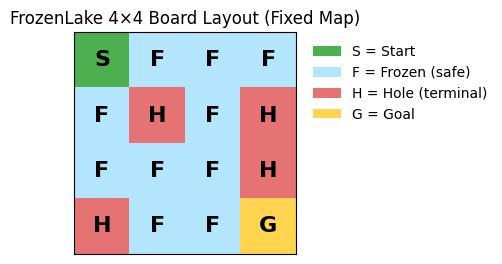

Board (text):
S F F F
F H F H
F F F H
H F F G


In [32]:
# Build env & fetch fixed board layout
env = gym.make("FrozenLake-v1", is_slippery=True)
desc = np.array(env.unwrapped.desc, dtype='U1')   # 4x4 array of 'S','F','H','G'

# Map tiles to integers for imshow
code = {'S': 0, 'F': 1, 'H': 2, 'G': 3}
grid = np.vectorize(code.get)(desc)

# Discrete colormap (S, F, H, G)
cmap = ListedColormap(['#4CAF50', '#B3E5FC', '#E57373', '#FFD54F'])
norm = BoundaryNorm(np.arange(-0.5, 4.5, 1), cmap.N)

# Plot
plt.figure(figsize=(4.5, 4.5))
plt.imshow(grid, cmap=cmap, norm=norm, interpolation='nearest')
plt.title("FrozenLake 4×4 Board Layout (Fixed Map)")
plt.xticks([]); plt.yticks([])

# Overlay tile letters
for i in range(desc.shape[0]):
    for j in range(desc.shape[1]):
        plt.text(j, i, desc[i, j], ha='center', va='center',
                 fontsize=16, fontweight='bold', color='black')

# Legend
legend_handles = [
    Patch(facecolor='#4CAF50', label='S = Start'),
    Patch(facecolor='#B3E5FC', label='F = Frozen (safe)'),
    Patch(facecolor='#E57373', label='H = Hole (terminal)'),
    Patch(facecolor='#FFD54F', label='G = Goal')
]
plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)

plt.tight_layout()
plt.show()

# (Optional) also print the text board to the console
print("Board (text):")
for row in desc:
    print(" ".join(row))

Greedy Policy (arrows):
← ↑ ↑ ↑
← ← ← ←
↑ ↓ ← ←
← → ↓ ←


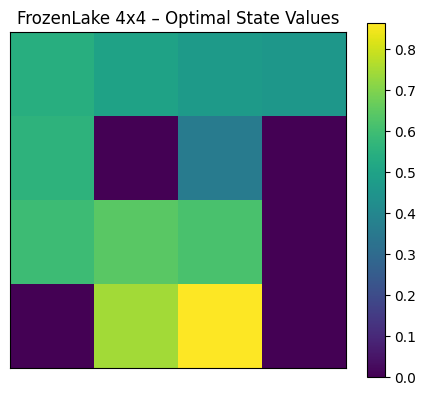

In [33]:
# Visuals: value heatmap + ASCII policy
def print_policy(pi):
    arrows = np.array(['←','↓','→','↑'])  # 0=L,1=D,2=R,3=U in FrozenLake
    side = int(math.sqrt(len(pi)))
    grid = arrows[pi].reshape(side, side)
    print("Greedy Policy (arrows):")
    for row in grid:
        print(" ".join(row))

def plot_values(V, title="State Values (V)"):
    side = int(math.sqrt(len(V)))
    plt.figure(figsize=(4.5,4))
    plt.imshow(V.reshape(side, side), cmap="viridis")
    plt.title(title)
    plt.colorbar()
    plt.xticks([]); plt.yticks([])
    plt.tight_layout()
    plt.show()

print_policy(pi)
plot_values(V, title="FrozenLake 4x4 – Optimal State Values")

The final visualization provides a view of the optimal policy and value function learned through Value Iteration. The arrow grid outlines the agent’s recommended moves from each tile, showing a clear strategy that guides it safely around holes and toward the goal (bottom right corner). Correspondingly, the heatmap displays the learned state values, where warmer colors near the goal indicate states with higher expected long-term rewards. This spatial representation confirms that the algorithm successfully identified safer, high-value paths despite environmental randomness.